Aquí importamos lo necesario y guardamos las imágenes que se van a usar

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)

ggris = cv2.GaussianBlur(gris, (3, 3), 0)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)
sobel = cv2.add(sobelx, sobely)
sobel8 = cv2.convertScaleAbs(sobel)
valorUmbral = 130

**Tarea 1:** Píxeles blancos por fila

0.4296875
12
512


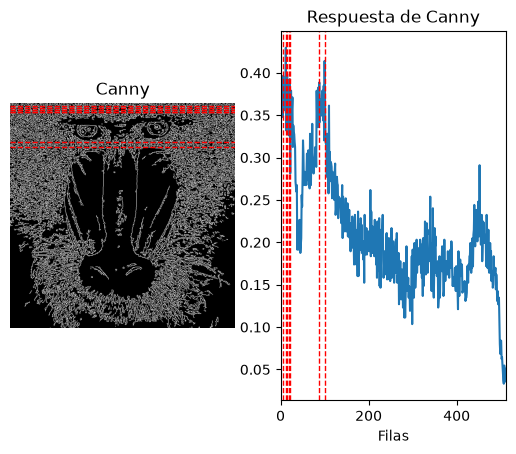

In [2]:
fil_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Cuando usas dim=1, el resultado de cv2.reduce tiene una forma vertical tipo matriz columna de tamaño (alto, 1)
filas = fil_counts[:, 0] / (255 * canny.shape[1])

print(filas.max())
print(filas.argmax()) #Encontrar el indice del valor maximo 
print(filas.shape[0]) #Numero de filas 


#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

for n in range(0, filas.shape[0]):
    if filas[n] > filas.max() * 0.90:
        plt.axhline(y=n, color='red', linestyle='--', linewidth=1)


plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(filas)

for n in range(0, filas.shape[0]):
    if filas[n] > filas.max() * 0.90:
        plt.axvline(x=n, color='red', linestyle='--', linewidth=1)

plt.xlim([0, canny.shape[0]])
plt.show()

**Tarea 2:** Canny y Sobel umbralizados

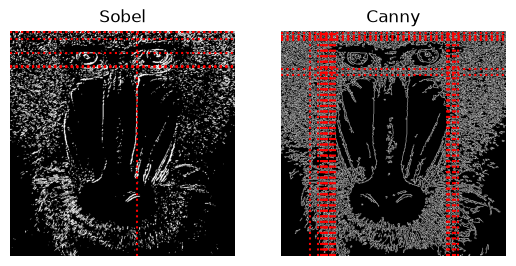

(0.0, 512.0)

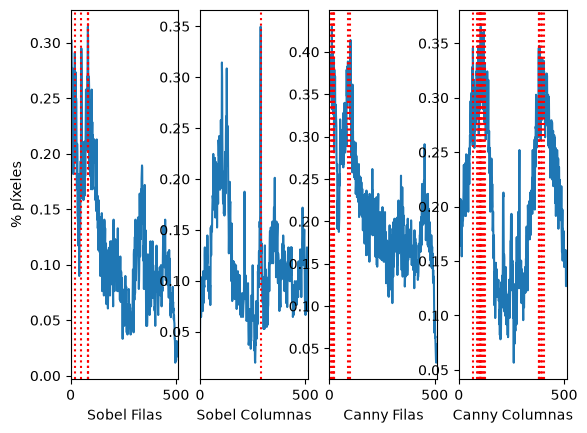

In [3]:
#Obtiene imagen umbralizada para dicho valor definido
_, imagenUmbralizadaSobel = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)
_, imagenUmbralizadaCanny = cv2.threshold(canny, valorUmbral, 255, cv2.THRESH_BINARY)

# Parámetros de Sobel
fil_counts = cv2.reduce(imagenUmbralizadaSobel, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts = cv2.reduce(imagenUmbralizadaSobel, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
sobel_fil = fil_counts[:, 0] / (255 * imagenUmbralizadaSobel.shape[1])
sobel_col = col_counts[0] / (255 * imagenUmbralizadaSobel.shape[0])

# Parámetros de Canny
fil_counts = cv2.reduce(imagenUmbralizadaCanny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts = cv2.reduce(imagenUmbralizadaCanny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
canny_fil = fil_counts[:, 0] / (255 * imagenUmbralizadaCanny.shape[1])
canny_col = col_counts[0] / (255 * imagenUmbralizadaCanny.shape[0])

# Muestra las imágenes
plt.subplot(1, 2, 1)
plt.title("Sobel")
plt.imshow(imagenUmbralizadaSobel, cmap='gray')
plt.axis("off")
for n in range(0, sobel_col.shape[0]):
    if sobel_col[n] >= sobel_col.max() * 0.9:
        plt.axvline(x=n, color='red', linestyle=':')
plt.xlim([0, imagenUmbralizadaSobel.shape[1]])
for n in range(0, sobel_fil.shape[0]):
    if sobel_fil[n] >= sobel_fil.max() * 0.9:
        plt.axhline(y=n, color='red', linestyle=':')
plt.ylim([imagenUmbralizadaSobel.shape[0], 0])

plt.subplot(1, 2, 2)
plt.title("Canny")
plt.imshow(imagenUmbralizadaCanny, cmap='gray')
plt.axis("off")
for n in range(0, canny_col.shape[0]):
    if canny_col[n] >= canny_col.max() * 0.9:
        plt.axvline(x=n, color='red', linestyle=':')
plt.xlim([0, imagenUmbralizadaCanny.shape[1]])
for n in range(0, canny_fil.shape[0]):
    if canny_fil[n] >= canny_fil.max() * 0.9:
        plt.axhline(y=n, color='red', linestyle=':')
plt.ylim([imagenUmbralizadaCanny.shape[0], 0])
plt.show()

# Muestra los histogramas de Sobel
plt.subplot(1, 4, 1)
plt.xlabel("Sobel Filas")
plt.ylabel("% píxeles")
plt.plot(sobel_fil)
for n in range(0, sobel_fil.shape[0]):
    if sobel_fil[n] >= sobel_fil.max() * 0.9:
        plt.axvline(x=n, color='red', linestyle=':')
plt.xlim([0, imagenUmbralizadaSobel.shape[0]])

plt.subplot(1, 4, 2)
plt.xlabel("Sobel Columnas")
plt.plot(sobel_col)
for n in range(0, sobel_col.shape[0]):
    if sobel_col[n] >= sobel_col.max() * 0.9:
        plt.axvline(x=n, color='red', linestyle=':')
plt.xlim([0, imagenUmbralizadaSobel.shape[1]])

# Muestra los histogramas de Canny
plt.subplot(1, 4, 3)
plt.xlabel("Canny Filas")
plt.plot(canny_fil)
for n in range(0, canny_fil.shape[0]):
    if canny_fil[n] >= canny_fil.max() * 0.9:
        plt.axvline(x=n, color='red', linestyle=':')
plt.xlim([0, imagenUmbralizadaCanny.shape[0]])

plt.subplot(1, 4, 4)
plt.xlabel("Canny Columnas")
plt.plot(canny_col)
for n in range(0, canny_col.shape[0]):
    if canny_col[n] >= canny_col.max() * 0.9:
        plt.axvline(x=n, color='red', linestyle=':')
plt.xlim([0, imagenUmbralizadaCanny.shape[1]])

**Tarea 3:** Esfera rebotante en cámara

In [4]:
vid = cv2.VideoCapture(0)

#estado inicial de la esfera
radio_esfera = 25
pos_x = 320.0
pos_y = 240.0
vel_x = 0.0
vel_y = 0.0
distancia_seguridad = 150  #distancia a la que la esfera empieza a huir del objeto

#rango de color azul en hsv
azul_bajo = np.array([95, 120, 70])
azul_alto = np.array([130, 255, 255])

while True:
    ret, frame = vid.read()

    if ret:
        #efecto espejo para que parezca un juegfo
        framem = cv2.flip(frame, 1)
        alto, ancho, _ = framem.shape

        #conversion de bgr a hsv
        hsv = cv2.cvtColor(framem, cv2.COLOR_BGR2HSV)

        #mascara para aislar el color azul
        mascara_objeto = cv2.inRange(hsv, azul_bajo, azul_alto)

        #deteccion de proyeccion en la mascara para los pixeles blancos
        filas = np.sum(mascara_objeto == 255, axis=1)
        columnas = np.sum(mascara_objeto == 255, axis=0)

        max_filas = filas.max()
        max_cols = columnas.max()

        #descartamos el ruido
        if max_filas > 20 and max_cols > 20:
            #umbralizamos al 90% nos aseguramos de que sea el objeto
            indices_y = [i for i in range(filas.shape[0]) if filas[i] >= max_filas * 0.90]
            indices_x = [j for j in range(columnas.shape[0]) if columnas[j] >= max_cols * 0.90]

            #centro del objeto
            obj_y = float(np.mean(indices_y))
            obj_x = float(np.mean(indices_x))

            #pintamos el circulo 
            cv2.circle(framem, (int(obj_x), int(obj_y)), 10, (255, 0, 0), 2)
            cv2.putText(framem, "Objeto Azul", (int(obj_x) + 12, int(obj_y)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1,)

            #vector desde el objeto hacia el circulo (direccion de escape)
            dx = pos_x - obj_x
            dy = pos_y - obj_y
            distancia = np.sqrt(dx**2 + dy**2)

            #si el objeto azul entra en ladistancia de seguridad, la pelota se aleja
            if distancia < distancia_seguridad and distancia > 1:
                fuerza_escape = (distancia_seguridad - distancia) / 8.0
                vel_x += (dx / distancia) * fuerza_escape
                vel_y += (dy / distancia) * fuerza_escape

        #fisicas para frenar la pelota progresivamente
        vel_x *= 0.90
        vel_y *= 0.90

        #actualizacion de la posicion 
        pos_x += vel_x
        pos_y += vel_y

        #rebotes de la pelota con las esquinas de la pantalla
        if pos_x < radio_esfera:
            pos_x = radio_esfera
            vel_x *= -1
        elif pos_x > ancho - radio_esfera:
            pos_x = ancho - radio_esfera
            vel_x *= -1

        if pos_y < radio_esfera:
            pos_y = radio_esfera
            vel_y *= -1
        elif pos_y > alto - radio_esfera:
            pos_y = alto - radio_esfera
            vel_y *= -1

        #printear la pelota
        centro_esfera = (int(pos_x), int(pos_y))
        cv2.circle(framem, centro_esfera, radio_esfera, (0, 255, 120), -1)
        cv2.circle(framem, centro_esfera, radio_esfera, (255, 255, 255), 2)

        #ambas ventanas (juego y mascara)
        cv2.imshow("Juego", framem)
        cv2.imshow("Mascara", mascara_objeto)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()